# Title:Quadratic Regression Using PyTorch


Objective

To build and train a quadratic (polynomial) regression model using PyTorch’s nn.Module, learn parameters from a dataset, and evaluate performance using Mean Absolute Error (MAE).




In this experiment, a quadratic model is implemented using PyTorch. The model learns two parameters (weight and bias) and uses the squared input value to make predictions. Training is done by minimizing the error between predicted and actual values using a loss function. The optimizer adjusts model parameters step by step to improve accuracy.


## Import libraries 

In [1]:
# Import PyTorch and matplotlib
import torch
import matplotlib.pyplot as plt
from torch import nn # nn contains all of PyTorch's building blocks for neural networks

# Check PyTorch version
torch.__version__

'2.12.0+cu126'

## Load dataset

In [2]:
# Setup device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")


Using device: cuda


In [3]:
import pandas as pd
import torch

df = pd.read_csv(r'assignment-data2.csv')
df.head(6)

,x,y
0,-9.8,673.28
1,-9.6,646.12
2,-9.4,619.52
3,-9.2,593.48
4,-9.0,568.00
5,-8.8,543.08


## Data preparation

In [4]:
# convert to torch tensors for use in the notebook
X = torch.tensor(df['x'].values, dtype=torch.float32).unsqueeze(1)
y = torch.tensor(df['y'].values, dtype=torch.float32).unsqueeze(1)
print(X.shape)
print(y.shape)

torch.Size([99, 1])
torch.Size([99, 1])


## Data splitting


In [5]:
# Split data
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

(79, 79, 20, 20)

## Visualization of training and testing data

In [6]:
def plot_predictions(train_data=X_train, 
                     train_labels=y_train, 
                     test_data=X_test, 
                     test_labels=y_test, 
                     predictions=None):
  """
  Plots training data, test data and compares predictions.
  """
  plt.figure(figsize=(10, 7))

  # Plot training data in blue
  plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")
  
  # Plot test data in green
  plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")

  if predictions is not None:
    # Plot the predictions in red (predictions were made on the test data)
    plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")

  # Show the legend
  plt.legend(prop={"size": 14});

In [7]:
import matplotlib.pyplot as plt

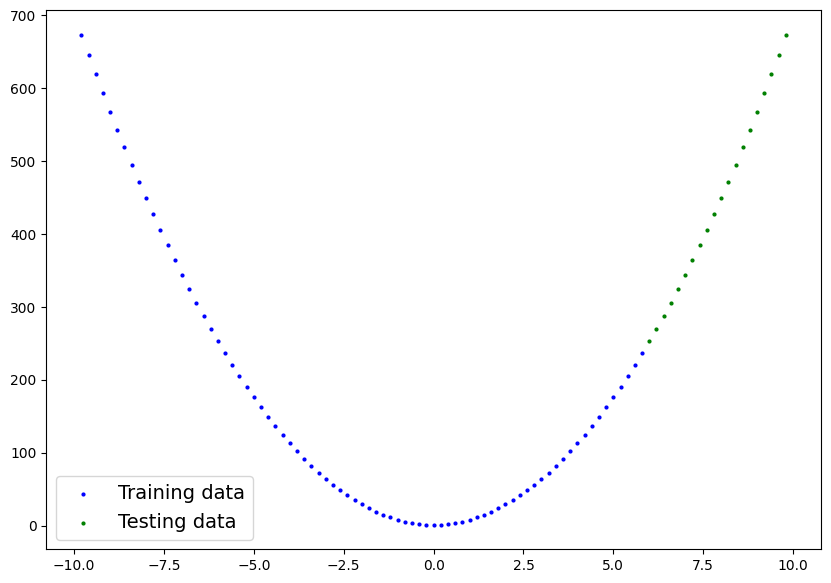

In [8]:
# Note: If you've reset your runtime, this function won't work, 
# you'll have to rerun the cell above where it's instantiated.
plot_predictions(X_train, y_train, X_test, y_test)

## Linear model class

In [9]:
# Create a Linear Regression model class
class LinearRegressionModel(nn.Module): # <- almost everything in PyTorch is a nn.Module (think of this as neural network lego blocks)
    def __init__(self):
        super().__init__() 
        self.weights = nn.Parameter(torch.randn(1, # <- start with random weights (this will get adjusted as the model learns)
                                    dtype=torch.float), # <- PyTorch loves float32 by default
                                    requires_grad=True) # <- can we update this value with gradient descent?)

        self.bias = nn.Parameter(torch.randn(1, # <- start with random bias (this will get adjusted as the model learns)
                                dtype=torch.float), # <- PyTorch loves float32 by default
                                requires_grad=True) # <- can we update this value with gradient descent?))

    # Forward defines the computation in the model
    def forward(self, x: torch.Tensor) -> torch.Tensor: # <- "x" is the input data (e.g. training/testing features)
        return self.weights * x**2+ self.bias # <- this is the linear regression formula (y = m*x + b

## Model initialization and inspection of parameter

In [10]:
# Set manual seed since nn.Parameter are randomly initialized
torch.manual_seed(42)

# Create an instance of the model (this is a subclass of nn.Module that contains nn.Parameter(s))
model_0 = LinearRegressionModel()

# Check the nn.Parameter(s) within the nn.Module subclass we created
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [11]:
print(model_0.weights.dtype)
print(model_0.bias.dtype)

torch.float32
torch.float32


## Initial prediction

In [12]:
# Make predictions with model
with torch.inference_mode(): 
    y_preds = model_0(X_test)

# Note: in older PyTorch code you might also see torch.no_grad()
# with torch.no_grad():
#   y_preds = model_0(X_test)

y_preds[:5]

tensor([[12.2497],
        [13.0712],
        [13.9196],
        [14.7950],
        [15.6974]])

In [13]:
# Check the predictions
print(f"Number of testing samples: {len(X_test)}") 
print(f"Number of predictions made: {len(y_preds)}")
print(f"Predicted values:\n{y_preds}")

Number of testing samples: 20
Number of predictions made: 20
Predicted values:
tensor([[12.2497],
        [13.0712],
        [13.9196],
        [14.7950],
        [15.6974],
        [16.6266],
        [17.5828],
        [18.5660],
        [19.5760],
        [20.6131],
        [21.6770],
        [22.7679],
        [23.8857],
        [25.0304],
        [26.2021],
        [27.4007],
        [28.6263],
        [29.8788],
        [31.1582],
        [32.4646]])


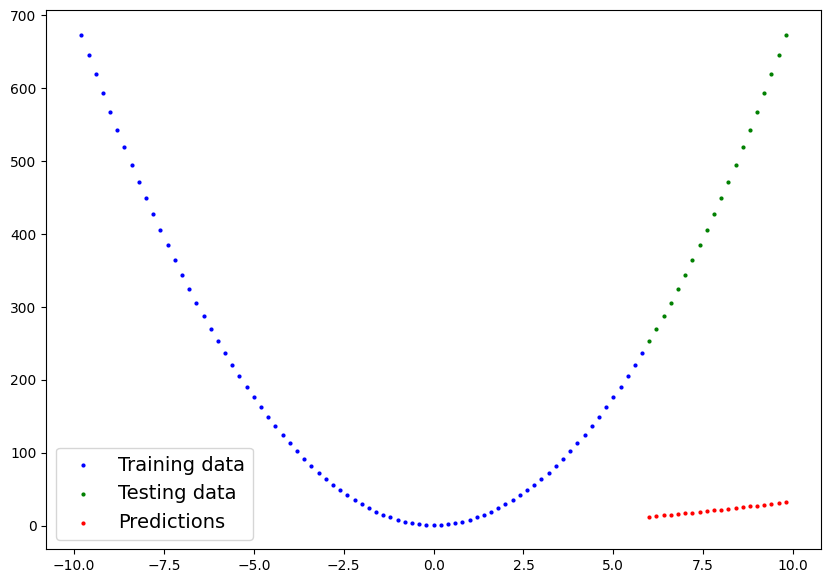

In [14]:
plot_predictions(predictions=y_preds)

## Configure loss function and optimizer

In [15]:
# Loss Function Selection
# Create the loss function
loss_fn = nn.L1Loss() # MAE loss is same as L1Loss

# Create the optimizer
optimizer = torch.optim.SGD(
                    params=model_0.parameters(), # parameters of target model to optimize
                    lr=0.01) # learning rate (how much the optimizer should change parameters at each step, higher=more (less stable), lower=less (might take a long time))

## Training and testing

In [16]:
torch.manual_seed(42)

# Set the number of epochs (how many times the model will pass over the training data)
epochs = 200

# Create empty loss lists to track values
train_loss_values = []
test_loss_values = []
epoch_count = []

for epoch in range(epochs):
    ### Training

    # Put model in training mode (this is the default state of a model)
    model_0.train()

    # 1. Forward pass on train data using the forward() method inside 
    y_pred = model_0(X_train)
    # print(y_pred)

    # 2. Calculate the loss (how different are our models predictions to the ground truth)
    loss = loss_fn(y_pred, y_train)

    # 3. Zero grad of the optimizer
    optimizer.zero_grad()

    # 4. Loss backwards
    loss.backward()

    # 5. Progress the optimizer
    optimizer.step()

    ### Testing

    # Put the model in evaluation mode
    model_0.eval()

    with torch.inference_mode():
      # 1. Forward pass on test data
      test_pred = model_0(X_test)

      # 2. Calculate loss on test data
      test_loss = loss_fn(test_pred, y_test.type(torch.float)) # predictions come in torch.float datatype, so comparisons need to be done with tensors of the same type

      # Print out what's happening every 10 epochs
      if epoch % 10 == 0:
            epoch_count.append(epoch)
            train_loss_values.append(loss.detach().numpy())
            test_loss_values.append(test_loss.detach().numpy())
            print(f"Epoch: {epoch} | MAE Train Loss: {loss} | MAE Test Loss: {test_loss} ")
            

Epoch: 0 | MAE Train Loss: 166.12127685546875 | MAE Test Loss: 409.7730407714844 
Epoch: 10 | MAE Train Loss: 104.51728057861328 | MAE Test Loss: 251.5978546142578 
Epoch: 20 | MAE Train Loss: 42.913272857666016 | MAE Test Loss: 93.42262268066406 
Epoch: 30 | MAE Train Loss: 3.944099187850952 | MAE Test Loss: 6.613184928894043 
Epoch: 40 | MAE Train Loss: 2.9400620460510254 | MAE Test Loss: 9.151992797851562 
Epoch: 50 | MAE Train Loss: 2.282644033432007 | MAE Test Loss: 10.805486679077148 
Epoch: 60 | MAE Train Loss: 1.7487810850143433 | MAE Test Loss: 12.143815994262695 
Epoch: 70 | MAE Train Loss: 1.3455159664154053 | MAE Test Loss: 13.149670600891113 
Epoch: 80 | MAE Train Loss: 0.9748930335044861 | MAE Test Loss: 14.072405815124512 
Epoch: 90 | MAE Train Loss: 0.6545260548591614 | MAE Test Loss: 14.867582321166992 
Epoch: 100 | MAE Train Loss: 0.4095451831817627 | MAE Test Loss: 15.471400260925293 
Epoch: 110 | MAE Train Loss: 2.292677879333496 | MAE Test Loss: 10.603215217590332 

## PLot the curve

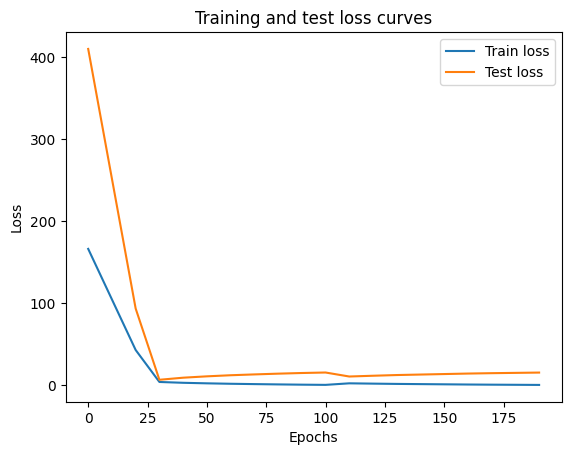

In [17]:
# Plot the loss curves
plt.plot(epoch_count, train_loss_values, label="Train loss")
plt.plot(epoch_count, test_loss_values, label="Test loss")
plt.title("Training and test loss curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend();

In [18]:
# Find our model's learned parameters
print("The model learned the following values for weights and bias:")
print(model_0.state_dict())
print("\nAnd the original values for weights and bias are:")
print(f"weights: 0.7, bias: 0.3")

The model learned the following values for weights and bias:
OrderedDict({'weights': tensor([7.0037]), 'bias': tensor([0.7116])})

And the original values for weights and bias are:
weights: 0.7, bias: 0.3


## Final prediction 

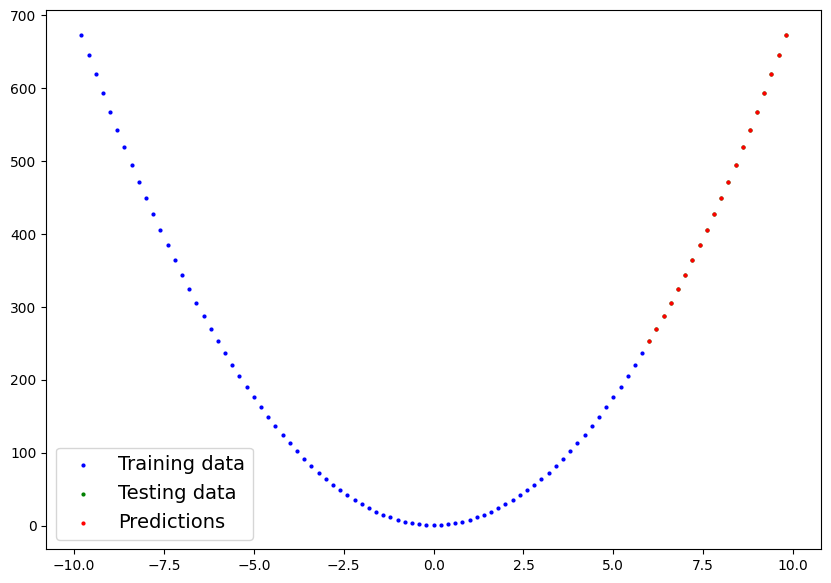

In [19]:
# 1. Set the model in evaluation mode
model_0.eval()

# 2. Setup the inference mode context manager
with torch.inference_mode():
  # 3. Make sure the calculations are done with the model and data on the same device
  # in our case, we haven't setup device-agnostic code yet so our data and model are
  # on the CPU by default.
  # model_0.to(device)
  # X_test = X_test.to(device)
  y_preds = model_0(X_test)
plot_predictions(predictions=y_preds)

## Discussion

As practical knowledge helps us to increase skill .here ,we perform quadratic regression using pytorchDuring training, the model initially produces poor predictions because the parameters are randomly assigned. As training continues, the error gradually reduces due to optimization using gradient descent.Both training and testing losses decrease over time, showing that the model is learning the pattern in the dataset effectively. The prediction curve becomes closer to the actual data points, indicating better performance. The final learned parameters are close to expected values, showing successful learning of the quadratic relationship.

## Conclusion

The quadratic regression model was successfully implemented using PyTorch. It learned the relationship between input and output data by minimizing MAE loss through SGD optimization.

The model produced accurate predictions after training, proving that PyTorch can effectively learn non-linear relationships. This experiment demonstrates the basic machine learning workflow: data preparation, model building, training, evaluation, and prediction.